# inicialización 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')  # allow importing from parent directory
from fun_gilles import *
import pickle
import pandas as pd

In [3]:
colors = plt.get_cmap('Set2').colors
plt.rcParams["axes.formatter.use_mathtext"] = True
plt.rcParams["axes.formatter.useoffset"]= False

In [4]:
title_fs = 16
label_fs = 15
tick_fs = 14
legend_fs = 14

In [5]:
f = '../examples/reactions_autocat.txt'
reactions = read_file(f)
species = obtain_species(reactions)

In [6]:
def load_streamed_pickle(filename):
    data = {}
    try:
        with open(filename, "rb") as file:
            while True:
                try:
                    # Load one object (which is a dict of {k_i: (abundances, times, volumes)})
                    chunk = pickle.load(file)
                    # Merge the loaded chunk into the main dictionary
                    data.update(chunk)
                except EOFError:
                    # Reached the end of the file
                    break
    except FileNotFoundError:
        print(f"Error: File '{filename}' not found.")
    
    print(f"Successfully loaded {len(data)} simulation results.")
    return data

In [7]:
def get_alpha_single_run(cond:float, result:tuple, values_used = None):
    _, times, volumes = result
        
    times = np.array(times)
    volumes = np.array(volumes)
    
    # Use data points from index len/5 onwards
    if values_used == None:
        start_idx = round(len(volumes) / 5)
        log_v = np.log(volumes[start_idx:])
        t_subset = times[start_idx:]
    
    else:
        values_used = round(len(volumes) * values_used)
        log_v = np.log(volumes[:values_used])
        t_subset = times[:values_used]
    
    # Perform linear regression
    # polyfit(x, y, 1) returns [slope, intercept]
    coefficients = np.polyfit(t_subset, log_v, 1)
    m_fit = coefficients[0]      # This is alpha (slope)
    log_A_fit = coefficients[1]  # This is the intercept
    A_fit = np.exp(log_A_fit)
    
    # --- R-SQUARED CALCULATION ---
    log_v_predicted = log_A_fit + m_fit * t_subset
    log_v_mean = np.mean(log_v)
    SS_res = np.sum((log_v - log_v_predicted)**2)
    SS_tot = np.sum((log_v - log_v_mean)**2)
    R_squared = 1 - (SS_res / SS_tot) if SS_tot != 0 else 0
    
    
    rmse = np.sqrt(SS_res / len(volumes)) if len(volumes) > 0 else 0
    
    # Return a dictionary directly
    return {
        'Condition': cond,
        'Alpha': m_fit,
        'Scaling Const. (A)': A_fit,
        'R^2': R_squared,
        'RMSE': rmse
    }

In [8]:
def plot_all_volumes(results: dict, k_i, xlim= None, ylim= None, lim= None, rep= 0, figname= None):
    if lim != None:
        filtered_conditions = [c for c in results.keys() if lim[0] < float(c) < lim[1]] 

    else:
        filtered_conditions = results
        
    i = k_i
    # Update the color gradient length
    color_gradient = plt.cm.rainbow(np.linspace(0, 1, len(filtered_conditions)))
    v_0 =None
    plt.figure(figsize=(5,4))
    # Then loop through filtered_conditions instead of results.items()
    for j, condition in enumerate(filtered_conditions):
        replicates = results[condition]
        formatted_label = f"${float(condition):.1e}$"
        
        if not isinstance(replicates, tuple):
            # for rep in replicates:
            if isinstance(replicates[rep], dict):
                data_tuple = list(replicates[rep].values())[0]
            else:
                data_tuple = replicates[rep]
            
            a, t, v = data_tuple
        else:
            a, t, v = replicates
            
            
            # print(fr"For simulation $k_{i}$ = {condition}") 
            # print(fr"-  Highest volume = {max(v)}")
            # print(fr"-  Lowest volume = {min(v)}")
        plt.plot(t, v, color=color_gradient[j], label=formatted_label, alpha = 0.9, linewidth= 2)    

    
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    sorted_labels = sorted(by_label.keys(), key=lambda x: float(x.replace('$', '').replace('{', '').replace('}', '')))
    sorted_handles = [by_label[k] for k in sorted_labels]
    plt.legend(sorted_handles, sorted_labels, title = rf"$k_{i+1}$", fontsize= legend_fs,
            loc='center left', bbox_to_anchor=(1.05, 0.5), title_fontsize= title_fs)
    if xlim != None:
        plt.xlim((0,xlim))

    if ylim!= None:
        plt.ylim(5e1, ylim)
    
    import matplotlib.ticker as ticker
    ax = plt.gca()
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    plt.yscale('log')
    # plt.xscale('log')
    plt.xlabel("Time", fontsize = label_fs)
    plt.ylabel("Volume", fontsize = label_fs)

    plt.tick_params(axis='both', labelsize= tick_fs)
    plt.savefig(f"../figures_TFM/vol_vs_time_k_{i+1}.png", bbox_inches='tight')
    plt.show()


# figures

Successfully loaded 25 simulation results.
       Condition    Alpha_mean     Alpha_std    R2_mean
0   1.000000e-05  2.675947e-01  1.887271e-03   0.999880
1   3.162278e-05  2.682473e-01  3.158919e-03   0.999856
2   1.000000e-04  2.674973e-01  2.727044e-03   0.999881
3   3.162278e-04  2.675670e-01  1.999967e-03   0.999853
4   1.000000e-03  2.673870e-01  3.396527e-03   0.999847
5   3.162278e-03  2.682771e-01  3.503867e-03   0.999863
6   1.000000e-02  2.661984e-01  2.882000e-03   0.999887
7   3.162278e-02  2.648484e-01  3.154387e-03   0.999915
8   1.000000e-01  2.572807e-01  2.720665e-03   0.999871
9   3.162278e-01  2.354165e-01  2.979331e-03   0.999824
10  1.000000e+00  1.816473e-01  3.467306e-03   0.999604
11  3.162278e+00  8.166494e-02  3.601210e-03   0.998485
12  1.000000e+01  1.372903e-02  2.513054e-03   0.977722
13  3.162278e+01  2.085604e-03  9.354135e-04   0.693399
14  1.000000e+02  3.503109e-04  9.048196e-04   0.431789
15  3.162278e+02 -5.115759e-06  3.465753e-04   0.451039
16  1

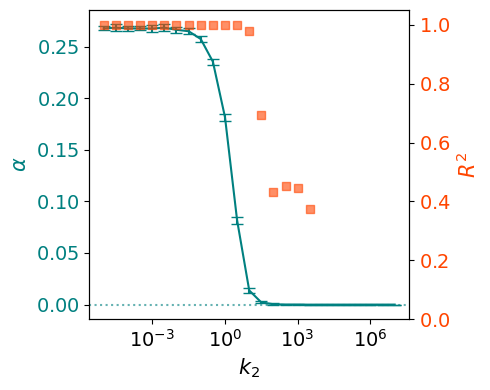

In [9]:
for i in [1]:
    results = load_streamed_pickle(f"barrido_k{i}_highiter.pkl")
    results.keys()
    len(results)
    # 1. Processing the statistical data
    # Assuming barrido_ab_k1_em4 is a dict: {concentration: [(ab, t, v), (ab, t, v), ...]}
    stats_results = []

    for condition, replicates in results.items():
        alphas = []
        r2_values = []
        if not isinstance(replicates, tuple):
            for rep in replicates:
                # If rep is a dictionary {cond: (ab, t, v)}, get the tuple:
                if isinstance(rep, dict):
                    # This gets the first value in the dict, which is your (ab, t, v) tuple
                    data_tuple = list(rep.values())[0]
                else:
                    data_tuple = rep
                    
                res = get_alpha_single_run(condition, data_tuple) 
                alphas.append(res['Alpha'])
                r2_values.append(res['R^2'])
        else:
            res = get_alpha_single_run(condition, replicates) 
            alphas.append(res['Alpha'])
            r2_values.append(res['R^2'])
        
        stats_results.append({
            'Condition': condition,
            'Alpha_mean': np.mean(alphas),
            'Alpha_std': np.std(alphas),
            'R2_mean': np.mean(r2_values)
        })

    # Convert to DataFrame or Sortable List for plotting
    stats_results = pd.DataFrame(stats_results).sort_values('Condition')
    print(stats_results)

    # 2. Plotting with Error Bars
    fig, ax1 = plt.subplots(figsize=(5,4))

    # Primary Axis: Alpha with Error Bars
    # if i == 0 or i == 1:
    #     j = 1
    # elif i == 2 or i == 3:
    #     j = 2
    # elif i == 4 or i == 5:
    #     j = 3
    # elif i == 6 or i == 7:
    #     j = 4
    
    # ax1.set_xlabel(fr'$K_{j}$', fontsize= label_fs)
    ax1.set_xlabel(fr'$k_{i+1}$', fontsize= label_fs)
    ax1.set_ylabel(r'$\alpha$', color="teal", fontsize= label_fs)

    ax1.errorbar(stats_results['Condition'], stats_results['Alpha_mean'], 
                yerr=stats_results['Alpha_std'], color="teal", capsize=4, label=r'Mean $\alpha$')
    # ax1.plot(stats_results['Condition'], stats_results['Alpha_mean'], color="teal")

    ax1.tick_params(axis='y', labelcolor="teal", labelsize= tick_fs)
    ax1.axhline(y=0, color="teal", alpha=0.6, linestyle=":")
    ax1.set_xscale('log')
    ax1.tick_params(axis= 'x', labelsize= tick_fs)
    # ax1.set_yscale('log')

    # Secondary Axis: R^2
    ax2 = ax1.twinx()  
    ax2.set_ylabel(r'$R^2$', color="orangered", fontsize= label_fs)  
    ax2.scatter(stats_results['Condition'], stats_results['R2_mean'], 
                color="orangered", marker='s', alpha=0.6)

    ax2.tick_params(axis='y', labelcolor="orangered", labelsize= tick_fs)
    ax2.set_ylim((0, 1.05))
    ax2.set_xscale('log')
    ax2.tick_params(axis= 'x', labelsize= tick_fs)

    fig.tight_layout()
    fig.savefig(f"../figures_TFM/alpha_vs_k_{i+1}.png", bbox_inches='tight')
    plt.show()

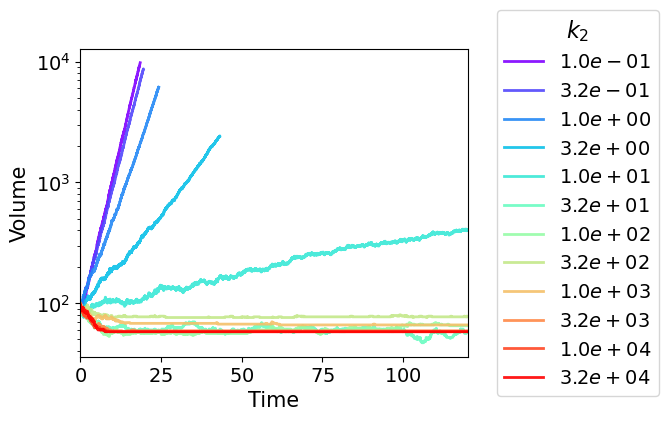

In [10]:
plot_all_volumes(results, i, 
                 xlim= 120,
                 lim= (5e-2, 1e5),
                 )

Successfully loaded 25 simulation results.


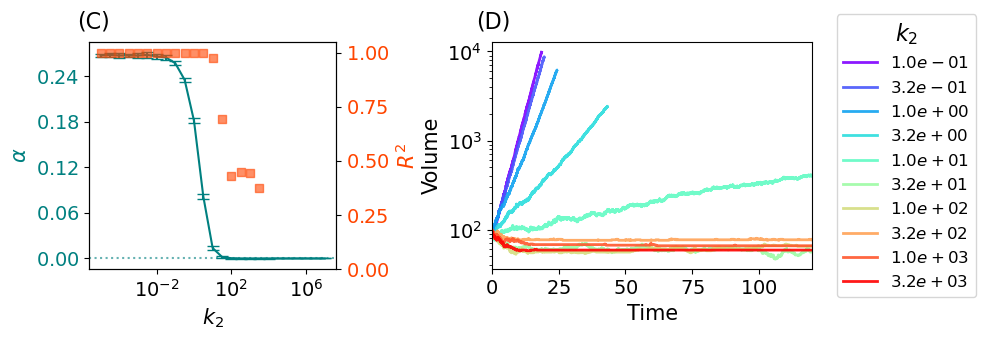

Successfully loaded 25 simulation results.


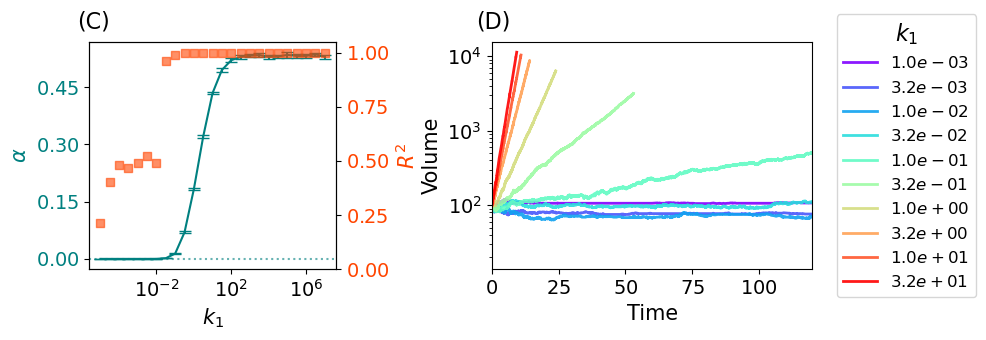

In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import numpy as np

def plot_combined_k_sweep_and_volumes(results: dict, k_i: int, xlim=None, ylim=None, lim=None, rep=0, figname=None):
    # Setup Figure: 1 row, 2 columns (widen to 10 to fit everything nicely)
    fig, axes = plt.subplots(1, 2, figsize=(10,3.5), gridspec_kw={'width_ratios': [1, 1.3]})    
    ax_sweep = axes[0]
    ax_vol = axes[1]
    
    # ==========================================
    # LEFT COLUMN: Alpha & R^2 Sweep
    # ==========================================
    stats_results = []
    
    for condition, replicates in results.items():
        alphas = []
        r2_values = []
        
        # Safely extract the (a, t, v) tuples matching your original logic
        if not isinstance(replicates, tuple):
            for r in replicates:
                if isinstance(r, dict):
                    data_tuple = list(r.values())[0]
                else:
                    data_tuple = r
                
                res = get_alpha_single_run(condition, data_tuple) 
                alphas.append(res['Alpha'])
                r2_values.append(res['R^2'])
        else:
            res = get_alpha_single_run(condition, replicates) 
            alphas.append(res['Alpha'])
            r2_values.append(res['R^2'])
        
        stats_results.append({
            'Condition': float(condition), # ensure numeric for sorting
            'Alpha_mean': np.mean(alphas),
            'Alpha_std': np.std(alphas),
            'R2_mean': np.mean(r2_values)
        })

    # Sort DataFrame by Condition so the line plots correctly
    df = pd.DataFrame(stats_results).sort_values('Condition')

    # Primary Axis: Alpha
    ax_sweep.set_xlabel(fr'$k_{{{k_i+1}}}$', fontsize=label_fs)
    ax_sweep.set_ylabel(r'$\alpha$', color="teal", fontsize=label_fs)
    ax_sweep.errorbar(df['Condition'], df['Alpha_mean'], yerr=df['Alpha_std'], 
                      color="teal", capsize=4, label=r'Mean $\alpha$')
    
    ax_sweep.tick_params(axis='y', labelcolor="teal", labelsize=tick_fs)
    ax_sweep.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))


    ax_sweep.axhline(y=0, color="teal", alpha=0.6, linestyle=":")
    ax_sweep.set_xscale('log')
    ax_sweep.tick_params(axis='x', labelsize=tick_fs)
    ax_sweep.set_title("(C)", loc="left",x = -0.05, y=1, pad=10, fontsize=16)


    # Secondary Axis: R^2
    ax2_sweep = ax_sweep.twinx()  
    ax2_sweep.set_ylabel(r'$R^2$', color="orangered", fontsize=label_fs)  
    ax2_sweep.scatter(df['Condition'], df['R2_mean'], color="orangered", marker='s', alpha=0.6)
    ax2_sweep.tick_params(axis='y', labelcolor="orangered", labelsize=tick_fs)
    ax2_sweep.set_ylim((0, 1.05))

    # ==========================================
    # RIGHT COLUMN: Volumes vs Time
    # ==========================================
    if lim is not None:
        filtered_conditions = [c for c in results.keys() if lim[0] < float(c) < lim[1]] 
    else:
        filtered_conditions = list(results.keys())
        
    # Sort conditions so the colormap maps smoothly from lowest to highest
    filtered_conditions = sorted(filtered_conditions, key=float)
    color_gradient = plt.cm.rainbow(np.linspace(0, 1, len(filtered_conditions)))

    for j, condition in enumerate(filtered_conditions):
        replicates = results[condition]
        formatted_label = f"${float(condition):.1e}$"
        
        # Tuple extraction logic exactly matching your original script
        if not isinstance(replicates, tuple):
            if isinstance(replicates[rep], dict):
                data_tuple = list(replicates[rep].values())[0]
            else:
                data_tuple = replicates[rep]
            a, t, v = data_tuple
        else:
            a, t, v = replicates
            
        ax_vol.plot(t, v, color=color_gradient[j], label=formatted_label, alpha=0.9, linewidth=2)    

    ax_vol.set_yscale('log')
    ax_vol.set_xlabel("Time", fontsize=label_fs)
    ax_vol.set_ylabel("Volume", fontsize=label_fs)
    ax_vol.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    ax_vol.tick_params(axis='both', labelsize=tick_fs)
    ax_vol.set_title("(D)", loc="left",x = -0.05, y=1, pad=10, fontsize=16)

    if xlim is not None:
        ax_vol.set_xlim((0, xlim))
    if ylim is not None:
        ax_vol.set_ylim((5e1, ylim))

    # Legend Processing
    handles, labels = ax_vol.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    
    # Sort legend numerically
    sorted_labels = sorted(by_label.keys(), key=lambda x: float(x.replace('$', '').replace('{', '').replace('}', '')))
    sorted_handles = [by_label[k] for k in sorted_labels]
    
    # Attach legend completely outside the plot
    ax_vol.legend(sorted_handles, sorted_labels, title=rf"$k_{{{k_i+1}}}$", fontsize=legend_fs-2,
                  loc='center left', bbox_to_anchor=(1.05, 0.5), title_fontsize=title_fs)

    # ==========================================
    # FINAL LAYOUT AND SAVE
    # ==========================================
    # Squeeze plots to the left 82% to fit the external legend on the right
    plt.tight_layout()#rect=[0, 0, 1, 1])
    
    if figname:
        plt.savefig(f"../figures_TFM/{figname}.png", bbox_inches='tight', dpi=300)
        
    plt.show()

# --- Example Usage ---
i=1
results = load_streamed_pickle(f"barrido_k{i}_highiter.pkl")
plot_combined_k_sweep_and_volumes(results, i, xlim=120, lim=(5e-2, 1e4), figname=f"alpha_and_vol_k_{i+1}")
i=0
results = load_streamed_pickle(f"barrido_k{i}_highiter.pkl")
plot_combined_k_sweep_and_volumes(results, i, xlim=120, lim=(5e-4, 1e2), figname=f"alpha_and_vol_k_{i+1}")